# **Day 42: Learning Curves and Statistical Model Comparison**
*Module 7 - Model Selection, Tuning and Explainability*

Two practical questions every project faces:
1. **Will more data help, or do I need a better model?** -> learning curves and validation curves.
2. **Is model B really better than model A, or is it noise?** -> proper statistical comparison.

> A learning curve shows how performance changes with more training data and tells us whether collecting more data will help. Statistical tests tell us whether one model is really better than another or just lucky.
>
> *Example:* If validation accuracy is still rising at 500 samples, a new field campaign is worth it; if it is flat, better features matter more.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.model_selection import learning_curve, validation_curve, RepeatedStratifiedKFold, StratifiedKFold, cross_val_score
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
rng = np.random.default_rng(42)
X, y = make_classification(5000, 20, n_informative=8, n_redundant=4, flip_y=0.05, random_state=0)

## **1. Learning Curves**
Plot training and validation scores against training-set size.

| Pattern | Diagnosis | Remedy |
|---|---|---|
| Both scores low, close together | **High bias** (underfitting) | More complex model, better features; more data will **not** help |
| Large gap, validation still rising | **High variance** (overfitting) | More data, regularisation, simpler model |
| Both high, small gap | Good fit | Done (or collect data to confirm a plateau) |

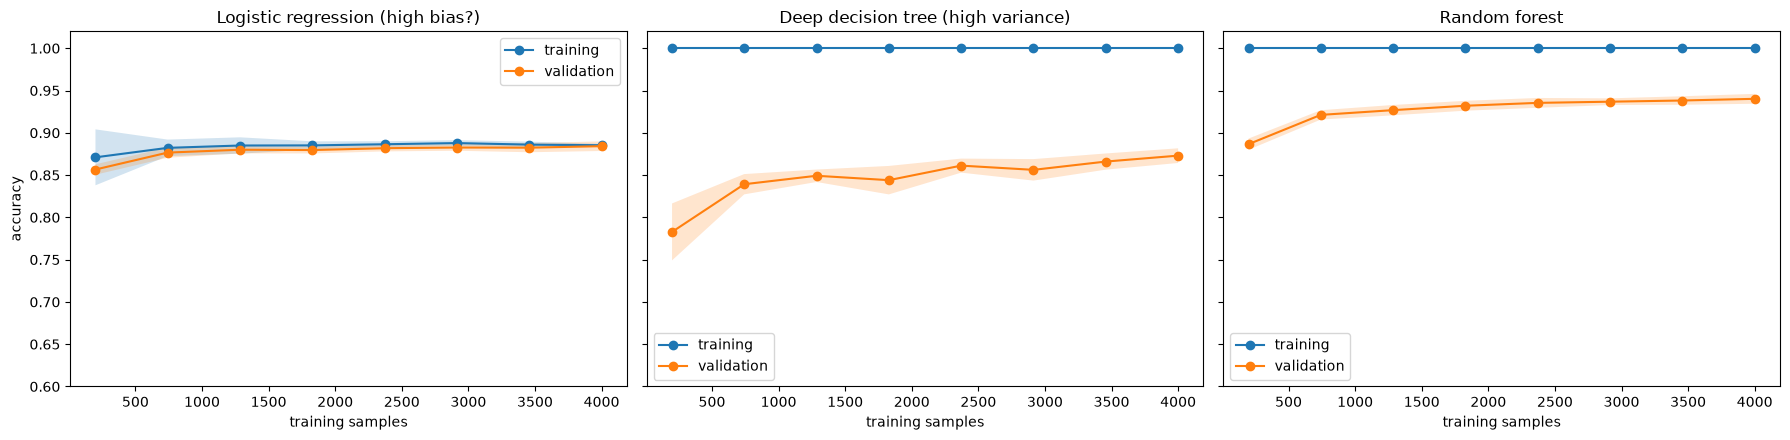

In [2]:
models = {"Logistic regression (high bias?)": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)),
          "Deep decision tree (high variance)": DecisionTreeClassifier(random_state=0),
          "Random forest": RandomForestClassifier(200, n_jobs=-1, random_state=0)}
fig, axes = plt.subplots(1, 3, figsize=(18, 4.5), sharey=True)
for ax, (name, m) in zip(axes, models.items()):
    sizes, tr, va = learning_curve(m, X, y, train_sizes=np.linspace(0.05, 1.0, 8), cv=5, n_jobs=-1, shuffle=True, random_state=0)
    for s, lab in [(tr, "training"), (va, "validation")]:
        ax.plot(sizes, s.mean(1), "o-", label=lab); ax.fill_between(sizes, s.mean(1) - s.std(1), s.mean(1) + s.std(1), alpha=0.2)
    ax.set(title=name, xlabel="training samples", ylim=(0.6, 1.02)); ax.legend()
axes[0].set_ylabel("accuracy"); plt.tight_layout(); plt.show()

- Logistic regression: curves converge early at a lower level: more data won't help; the **model** limits performance.
- Deep tree: training accuracy 100%, big gap: overfitting.
- Random forest: gap shrinking, validation still rising: **more data would still help**.

## **2. Validation Curves**

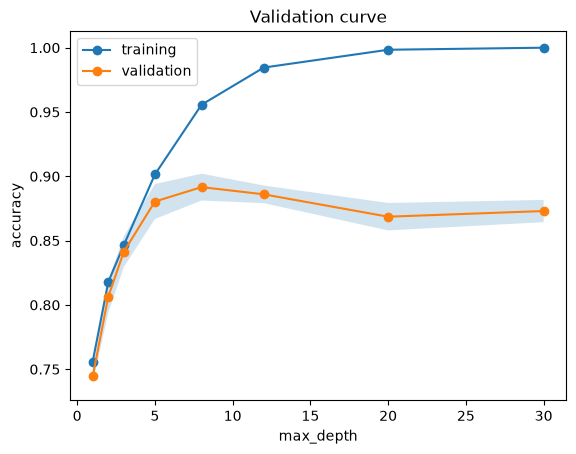

In [3]:
param_range = [1, 2, 3, 5, 8, 12, 20, 30]
tr, va = validation_curve(DecisionTreeClassifier(random_state=0), X, y, param_name="max_depth", param_range=param_range, cv=5, n_jobs=-1)
plt.plot(param_range, tr.mean(1), "o-", label="training"); plt.plot(param_range, va.mean(1), "o-", label="validation")
plt.fill_between(param_range, va.mean(1) - va.std(1), va.mean(1) + va.std(1), alpha=0.2)
plt.xlabel("max_depth"); plt.ylabel("accuracy"); plt.legend(); plt.title("Validation curve"); plt.show()

## **3. Comparing Two Models Properly**
We have K-fold scores for models A and B. The tempting test is a **paired t-test on the fold differences**. But folds share training data, so the differences are **correlated** and the variance is underestimated: the test reports "significant" far too often.

**Corrected resampled t-test** (Nadeau & Bengio, 2003), for $J$ = (repeats x folds) differences $d_j$:
$$t = \frac{\bar d}{\sqrt{\left(\frac{1}{J} + \frac{n_{test}}{n_{train}}\right)\hat\sigma_d^2}}$$

Let us check this directly. We draw 25 independent datasets from the same population and run 3x10-fold CV on each, comparing logistic regression with kNN. The **true** variability of the CV mean difference is its standard deviation **across datasets**. A good standard error computed from **one** dataset should match it.

In [4]:
def corrected_ttest(diffs, n_train, n_test):
    J = len(diffs); d_bar = diffs.mean(); var = diffs.var(ddof=1)
    t = d_bar / np.sqrt((1 / J + n_test / n_train) * var)
    return t, 2 * stats.t.sf(abs(t), J - 1)

model_a = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000))
model_b = make_pipeline(StandardScaler(), KNeighborsClassifier(15))
mean_diffs, naive_se, corrected_se = [], [], []
for trial in range(25):
    idx_t = rng.choice(len(y), 500, replace=False)
    cvr = RepeatedStratifiedKFold(n_splits=10, n_repeats=3, random_state=trial)
    d = cross_val_score(model_a, X[idx_t], y[idx_t], cv=cvr, n_jobs=-1) - cross_val_score(model_b, X[idx_t], y[idx_t], cv=cvr, n_jobs=-1)
    J = len(d)
    mean_diffs.append(d.mean())
    naive_se.append(d.std(ddof=1) / np.sqrt(J))                               # assumes 30 independent differences
    corrected_se.append(np.sqrt((1 / J + 1 / 9) * d.var(ddof=1)))              # Nadeau-Bengio: n_test / n_train = 1/9
print(f"true SD of the CV mean difference across datasets: {np.std(mean_diffs, ddof=1):.4f}")
print(f"average naive standard error (one dataset)       : {np.mean(naive_se):.4f}  <- too small")
print(f"average corrected standard error (one dataset)   : {np.mean(corrected_se):.4f}")

true SD of the CV mean difference across datasets: 0.0130
average naive standard error (one dataset)       : 0.0072  <- too small
average corrected standard error (one dataset)   : 0.0150


The naive standard error is only about half the real variability, so naive p-values are far too small and "significant" differences are often noise. The corrected version is much closer to reality (it is still approximate: Bengio & Grandvalet, 2004, proved no unbiased estimator exists).

### A real comparison

In [5]:
def compare(model_a, model_b, X, y, seed, n_repeats=10):
    cvr = RepeatedStratifiedKFold(n_splits=10, n_repeats=n_repeats, random_state=seed)
    a = cross_val_score(model_a, X, y, cv=cvr, n_jobs=-1); b = cross_val_score(model_b, X, y, cv=cvr, n_jobs=-1)
    d = a - b
    naive_p = stats.ttest_rel(a, b).pvalue
    n_tr = int(len(y) * 0.9); _, corr_p = corrected_ttest(d, n_tr, len(y) - n_tr)
    return naive_p, corr_p, d.mean()

idx = rng.choice(len(y), 1500, replace=False)
pn, pc, dm = compare(make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), RandomForestClassifier(200, n_jobs=-1, random_state=0), X[idx], y[idx], seed=0)
print(f"LogReg - RF mean accuracy difference {dm:+.4f} | naive p = {pn:.2e} | corrected p = {pc:.2e}")

LogReg - RF mean accuracy difference -0.0392 | naive p = 1.35e-35 | corrected p = 2.01e-07


## **4. The 5x2cv Paired t-Test (Dietterich, 1998)**
Five repetitions of 2-fold CV; uses only the first fold's difference in the numerator and the variance of all ten. Low type-I error, moderate power.

In [6]:
def five_by_two_cv(model_a, model_b, X, y, seed=0):
    from sklearn.base import clone
    diffs, variances = [], []
    for r in range(5):
        skf = StratifiedKFold(2, shuffle=True, random_state=seed + r); d_r = []
        for tr, te in skf.split(X, y):
            d_r.append(clone(model_a).fit(X[tr], y[tr]).score(X[te], y[te]) - clone(model_b).fit(X[tr], y[tr]).score(X[te], y[te]))
        diffs.append(d_r); variances.append((d_r[0] - np.mean(d_r)) ** 2 + (d_r[1] - np.mean(d_r)) ** 2)
    t = diffs[0][0] / np.sqrt(np.mean(variances))
    return t, 2 * stats.t.sf(abs(t), 5)
t52, p52 = five_by_two_cv(make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), RandomForestClassifier(200, n_jobs=-1, random_state=0), X[idx], y[idx])
print(f"5x2cv t = {t52:.2f}, p = {p52:.4f}")

5x2cv t = -7.44, p = 0.0007


## **5. Many Models, Many Datasets: Friedman + Nemenyi**
To claim "algorithm A is generally better", compare across **many datasets**. Demsar (2006): rank the algorithms on each dataset, test with the **Friedman test**, then compare average ranks with the **Nemenyi critical difference (CD)**:
$$CD = q_\alpha\sqrt{\frac{k(k+1)}{6N}}$$

Average rank (1 = best):
 RF            1.71
HistGB        2.04
LogReg        3.42
Tree          4.42
kNN           4.62
NaiveBayes    4.79
dtype: float64

Friedman test: chi2 = 31.41, p = 7.77e-06


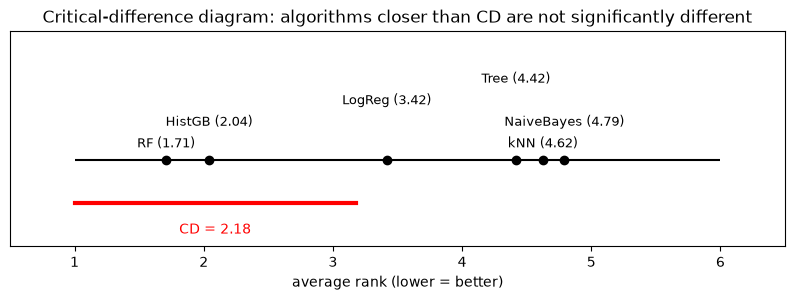

In [7]:
algos = {"LogReg": make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), "kNN": make_pipeline(StandardScaler(), KNeighborsClassifier(15)),
         "NaiveBayes": GaussianNB(), "Tree": DecisionTreeClassifier(max_depth=8, random_state=0),
         "RF": RandomForestClassifier(150, n_jobs=-1, random_state=0), "HistGB": HistGradientBoostingClassifier(random_state=0)}
scores = []
for d in range(12):                                                  # 12 synthetic "datasets" with different properties
    Xd, yd = make_classification(600, rng.integers(12, 40), n_informative=rng.integers(3, 8), flip_y=rng.uniform(0, 0.1),
                                 class_sep=rng.uniform(0.5, 1.5), n_clusters_per_class=rng.integers(1, 4), random_state=d)
    scores.append({k: cross_val_score(m, Xd, yd, cv=5, n_jobs=-1).mean() for k, m in algos.items()})
S = pd.DataFrame(scores)
ranks = S.rank(axis=1, ascending=False)
print("Average rank (1 = best):\n", ranks.mean().sort_values().round(2))
chi2, p_f = stats.friedmanchisquare(*[S[c] for c in S])
print(f"\nFriedman test: chi2 = {chi2:.2f}, p = {p_f:.2e}")
k, N = S.shape[1], S.shape[0]
q_alpha = {2: 1.960, 3: 2.343, 4: 2.569, 5: 2.728, 6: 2.850, 7: 2.949, 8: 3.031}[k]      # Nemenyi critical values (alpha=0.05)
CD = q_alpha * np.sqrt(k * (k + 1) / (6 * N))
avg = ranks.mean().sort_values()
fig, ax = plt.subplots(figsize=(10, 2.8))
ax.hlines(0, 1, k, color="k"); ax.set_xlim(0.5, k + 0.5); ax.set_ylim(-1, 1.5); ax.set_yticks([])
for i, (name, r) in enumerate(avg.items()):
    ax.plot(r, 0, "ko"); ax.text(r, 0.15 + 0.25 * (i % 4), f"{name} ({r:.2f})", ha="center", fontsize=9)
ax.plot([1, 1 + CD], [-0.5, -0.5], "r-", lw=3); ax.text(1 + CD / 2, -0.85, f"CD = {CD:.2f}", ha="center", color="r")
ax.set_xlabel("average rank (lower = better)"); ax.set_title("Critical-difference diagram: algorithms closer than CD are not significantly different")
plt.show()

# **Part 2: Going Deeper - Bayesian Comparison with a ROPE**

p-values answer "is the difference exactly zero?", which is rarely the question. Benavoli et al. (2017) recommend a **Bayesian correlated t-test**: the posterior of the mean difference is a Student-t with the Nadeau-Bengio variance correction. With a **Region of Practical Equivalence** (ROPE, e.g. +/-1% accuracy) we get three probabilities: A better, practically equivalent, B better.

In [8]:
def bayesian_correlated_ttest(diffs, rho, rope=0.01):
    J = len(diffs); mean = diffs.mean(); var = diffs.var(ddof=1)
    scale = np.sqrt((1 / J + rho / (1 - rho)) * var)
    post = stats.t(df=J - 1, loc=mean, scale=scale)
    return {"P(A better)": float(1 - post.cdf(rope)), "P(equivalent)": float(post.cdf(rope) - post.cdf(-rope)), "P(B better)": float(post.cdf(-rope))}

cvr = RepeatedStratifiedKFold(n_splits=10, n_repeats=10, random_state=0)
a = cross_val_score(RandomForestClassifier(200, n_jobs=-1, random_state=0), X[idx], y[idx], cv=cvr, n_jobs=-1)
b = cross_val_score(HistGradientBoostingClassifier(random_state=0), X[idx], y[idx], cv=cvr, n_jobs=-1)
res = bayesian_correlated_ttest(a - b, rho=1 / 10, rope=0.01)
print("A = Random Forest, B = HistGradientBoosting:", {k: round(v, 3) for k, v in res.items()})

A = Random Forest, B = HistGradientBoosting: {'P(A better)': 0.052, 'P(equivalent)': 0.939, 'P(B better)': 0.009}


A typical, honest conclusion: "With 99% probability the two models are within 1 percentage point of each other." That is far more useful for a paper than "p = 0.03".

## **Practice Problems**
1. Plot learning curves for `KNeighborsClassifier(1)` and `KNeighborsClassifier(50)`. Which is high-variance and which is high-bias?
2. Run the corrected t-test for LogReg vs RF with only 300 samples. Is the difference still significant?
3. Add a 7th algorithm (`ExtraTreesClassifier`) to the Friedman analysis. Recompute the CD (k = 7).
4. *(Advanced)* Use a ROPE of 0.5% and 2% in the Bayesian test. How do the probabilities change?

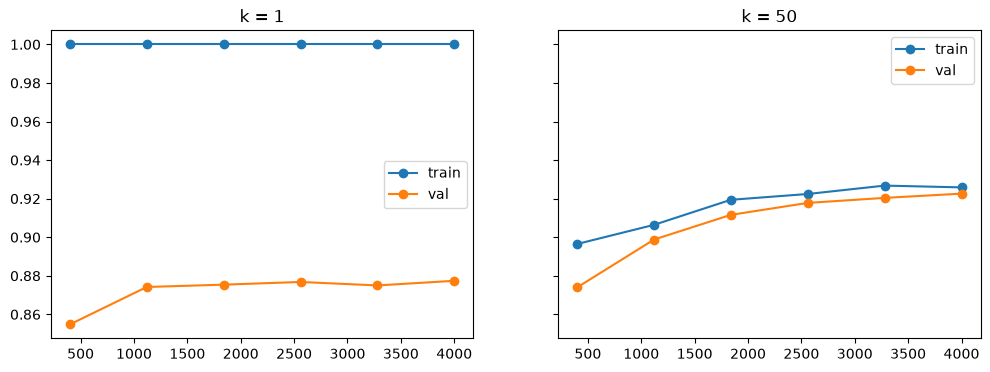

n=300: diff -0.0247, corrected p 0.190
ROPE 0.5%: {'P(A better)': 0.264, 'P(equivalent)': 0.652, 'P(B better)': 0.084}
ROPE 2.0%: {'P(A better)': 0.0, 'P(equivalent)': 1.0, 'P(B better)': 0.0}


In [9]:
# Solution 1
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for ax, k_ in zip(axes, [1, 50]):
    sz, tr_, va_ = learning_curve(make_pipeline(StandardScaler(), KNeighborsClassifier(k_)), X, y, train_sizes=np.linspace(0.1, 1, 6), cv=5, n_jobs=-1)
    ax.plot(sz, tr_.mean(1), "o-", label="train"); ax.plot(sz, va_.mean(1), "o-", label="val"); ax.set_title(f"k = {k_}"); ax.legend()
plt.show()
# Solution 2
idx3 = rng.choice(len(y), 300, replace=False)
pn3, pc3, dm3 = compare(make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000)), RandomForestClassifier(200, n_jobs=-1, random_state=0), X[idx3], y[idx3], seed=1)
print(f"n=300: diff {dm3:+.4f}, corrected p {pc3:.3f}")
# Solution 4
for rope in [0.005, 0.02]:
    print(f"ROPE {rope:.1%}:", {k_: round(v, 3) for k_, v in bayesian_correlated_ttest(a - b, 0.1, rope).items()})

## **Key References**
- Nadeau, C., & Bengio, Y. (2003). Inference for the generalization error. *Machine Learning*, 52(3), 239-281.
- Dietterich, T. G. (1998). Approximate statistical tests for comparing supervised classification learning algorithms. *Neural Computation*, 10(7), 1895-1923.
- Demsar, J. (2006). Statistical comparisons of classifiers over multiple data sets. *JMLR*, 7, 1-30.
- Benavoli, A., Corani, G., Demsar, J., & Zaffalon, M. (2017). Time for a change: a tutorial for comparing multiple classifiers through Bayesian analysis. *JMLR*, 18(77), 1-36.
- Bouckaert, R. R., & Frank, E. (2004). Evaluating the replicability of significance tests for comparing learning algorithms. *PAKDD 2004*.